In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from tqdm import tqdm

import importlib

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches


PATH = "../data_clean/"

In [2]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [3]:
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=10.0)

In [4]:
importlib.reload(gm)
importlib.reload(wt)

<module 'w1_tree' from '/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/w1_tree.py'>

In [5]:
# df_country_dist_list = []
# for year_loop in tqdm(year_list):
#     for mode_loop in ["individual", "collaborative"]:
#         df_tmp = df_prob.xs((year_loop, mode_loop), level=(1, 2))
#         df_country_dist_list.append(w1_tree.dist(df_tmp, df_tmp).assign(year=year_loop, mode=mode_loop).reset_index(names=["country"]))
# df_country_dist = pd.concat(df_country_dist_list).set_index(["country", "year", "mode"])

In [6]:
# df_dist = df_country_dist

In [7]:
# mode = "collaborative"
mode = "individual"
res = gm.GlobalMapping(df_dist.xs(mode, level=2),
                       df_prob.xs(mode, level=2),
                       df_total[[mode]].rename(columns={mode: "total"}), 
                       w1_tree.dist, lambda df: w1_tree.barycenter(df, init_step_size=0.001),)

In [8]:
# res._df_mapping.to_csv(PATH+"df_mapping_collab.csv", index=False)

In [9]:
year = 2023
df_plot_mapping = res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2")

In [10]:
# # year = 2023

# fig = px.choropleth(
#     df_plot_mapping.assign(cluster_str=lambda df: df.dynamic_cluster.astype(str)),
#     locations="alpha-3",
#     color="cluster_str",
#     locationmode="ISO-3",
#     color_continuous_scale="Plasma",
#     title="Clusters: "+str(year)
# )
# fig.update_layout(
#     margin=dict(l=0, r=0, t=30, b=0)
# )
# fig.show()

In [11]:
# df_mapping_tmp.query("dynamic_cluster == 4").xs(2018).merge(df_country[["alpha-2", "name"]], left_on="country", right_on="alpha-2", how="left")

In [12]:
# df_plot = res._df_mapping.groupby(["year", "dynamic_cluster"], as_index=False).country.count()

In [13]:
# # df_plot = df

# fig = px.area(
#     df_plot,
#     x="year",
#     y="country",
#     color="dynamic_cluster",
#     title="Cluster share over time (countries)"
# )

# # fig.update_layout(
# #     yaxis_range=[0, 1],
# #     xaxis_title="Year",
# #     yaxis_title="Share"
# # )

# fig.show()

In [14]:
df_tmp = df_prob.reset_index().merge(res._df_mapping[["country", "year"]], on=["country", "year"]).drop(columns="country").groupby(["year", "mode"]).mean()
df_tmp = df_tmp.div(df_tmp.sum(axis=1), axis=0)

In [15]:
index_year = df_tmp.xs("individual", level=1).index.to_list()

In [16]:
df_prob_mapping = (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year"])
)

In [17]:
# df_dist_global = w1_tree.dist(df_prob_mapping, df_global)

In [18]:
# df_dist_global.index = pd.MultiIndex.from_tuples(df_dist_global.index, names=["country", "year"])

In [19]:
# df_dist_global_clean = (
#     df_dist_global
#     .reset_index()
#     .melt(id_vars=["country", "year"])
#     .rename(columns={"second": "year_global", "value": "dist_global"})
#     .query("year == year_global")
#     .drop(columns=["year_global"])
# )

In [20]:
# df = df_cs.xs(mode, level=2).groupby(level=1).sum().div(df_cs.xs(mode, level=2).groupby(level=1).sum().sum(axis=1), axis=0)
# df = (
#     df_prob.xs(mode, level=2)
#     .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
#     .set_index(["country", "year", "dynamic_cluster"])
#     .groupby(level=1)
#     .mean()
# )


# # df = (
# #     df_prob.xs(mode, level=2)
# #     .loc[country_list]
# #     .groupby(level=1)
# #     .mean()
# # )

# df = df.div(df.sum(axis=1), axis=0)



# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=0,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [21]:
# df_years_dist = pd.read_csv(PATH+"df_dist_year.csv")

In [22]:
# df_years_dist = df_years_dist.query("((year_from + 1) == year_to) and (mode == 'individual')")[["country", "year_to", "distance"]]

In [23]:
# plt.subplots(figsize=(12, 5))
# country_list = ["US", "RU", "GB", "IN", "CN", "IT", "FR", "ID"]
# for country in country_list:
#     plt.plot(df_plot.query("country == @country").year, df_plot.query("country == @country").distance, label=country, alpha=0.7)
# plt.plot(df_dist.index, df_dist.distance, color="black", label="Global (all)")
# plt.legend()
# plt.grid()

In [24]:
# df = res._df_dyn_barycenters.xs(5, level=1)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=0,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [25]:
# df = res._df_dyn_barycenters.xs(1, level=1)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=0,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [26]:
# df = (res._df_dyn_barycenters.xs(2, level=1) - res._df_dyn_barycenters.xs(1, level=1)).dropna(how="all")

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="RdBu",
#         zmin=-0.02,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [27]:
df_subfield.query("subfield_id == 2740")

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
170,2740,Pulmonary and Respiratory Medicine,27,Medicine,4,Health Sciences


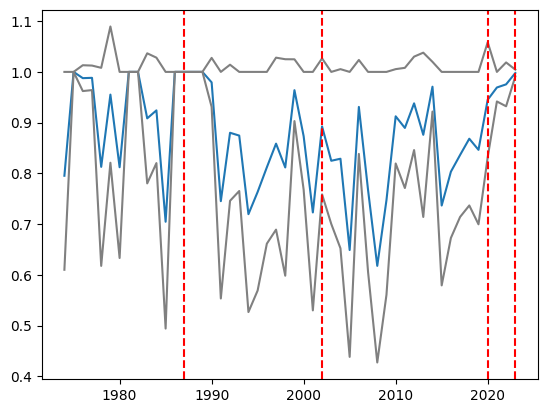

In [28]:
plt.plot(res._year_list, res._ari_score_mean)
plt.plot(res._year_list, np.maximum(np.array(res._ari_score_mean)+np.array(res._ari_score_std), 1), color="grey")
plt.plot(res._year_list, np.array(res._ari_score_mean)-np.array(res._ari_score_std), color="grey")
plt.axvline(1987, color="red", linestyle="--")
plt.axvline(2002, color="red", linestyle="--")
plt.axvline(2020, color="red", linestyle="--")
plt.axvline(2023, color="red", linestyle="--")

# Metric

In [29]:
df_prob_full = (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
)

In [30]:
importlib.reload(rm)

<module 'representation_metrics' from '/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/representation_metrics.py'>

In [31]:
domain_mapping = dict(zip(df_subfield.subfield_id, df_subfield.domain_name))

In [32]:
# df_prob_full = df_prob_full.groupby(domain_mapping, axis=1).sum()

In [33]:
df_subfield

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1597,1100,General Agricultural and Biological Sciences,11,Agricultural and Biological Sciences,1,Life Sciences
341,1102,Agronomy and Crop Science,11,Agricultural and Biological Sciences,1,Life Sciences
156,1103,Animal Science and Zoology,11,Agricultural and Biological Sciences,1,Life Sciences
269,1104,Aquatic Science,11,Agricultural and Biological Sciences,1,Life Sciences
7,1105,"Ecology, Evolution, Behavior and Systematics",11,Agricultural and Biological Sciences,1,Life Sciences
...,...,...,...,...,...,...
2398,3609,Occupational Therapy,36,Health Professions,4,Health Sciences
1434,3611,Pharmacy,36,Health Professions,4,Health Sciences
525,3612,"Physical Therapy, Sports Therapy and Rehabilit...",36,Health Professions,4,Health Sciences
865,3614,Radiological and Ultrasound Technology,36,Health Professions,4,Health Sciences


In [34]:
sc = rm.SomeClass(np.log(df_prob_full.replace({0: np.nan})))
sc.get_metric(level_agg = 2, level_norm = 1)
df_metric = sc._df_metric
sc.get_pos_metric(0)
sc.get_pos_metric_norm()

In [35]:
# df_prob_full = np.log(df_prob_full.replace({0:np.nan}))

In [36]:
# df_norm = df_prob_full.groupby(level=1).mean()
# df_n_norm = df_prob_full.sum(axis=1).groupby(level=1).count()
        
# df_agg = df_prob_full.groupby(level=[1, 2]).mean()
# df_n_agg = df_prob_full.sum(axis=1).groupby(level=[1, 2]).count()
    
# df_agg_mapping = df_agg.reset_index()[["year", "dynamic_cluster"]]

# df_norm_var = (
#     df_prob_full.groupby(level=1).var()
#     .merge(df_agg_mapping, left_index=True, right_on="year", how="outer")
#     .set_index(["year", "dynamic_cluster"])
# )
        
# df_mult1 = ((df_n_norm - df_n_agg) / df_n_agg / (df_n_norm - 1))

# df_mult = np.sqrt(df_norm_var.mul(df_mult1, axis=0))
        
# df_metric = (df_agg - df_norm) / df_mult

In [37]:
sf_list = df_subfield.sort_values(["domain_id", "field_id", "subfield_id"]).subfield_id.to_list()

In [38]:
# # df = df_metric.xs("FR", level=1)
# cluster = 4
# df = df_metric.xs(cluster, level=1)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="RdBu",
#         zmin=-15,
#         zmax=15,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [39]:
# df = res._df_dyn_barycenters.xs(cluster, level=1)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Blues",
#         zmin=0,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [40]:
# # df = df_metric.xs("FR", level=1)
# # cluster = 4
# df = sc._pos_metric.xs(cluster, level=1)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Blues",
#         zmin=0,
#         zmax=2,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [41]:
sc._pos_metric_norm.xs(2023, level=0)

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,1212,2104,1409,2922,1410,2402,2714,1200,2718,3002
dynamic_cluster,,,,,,,,,,,,,,,,,,,,,
-1,0.221704,NaN,0.867274,0.445712,0.574982,0.303476,0.400268,0.392316,0.588521,0.766904,...,0.257192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.046283,1.0,0.000000,1.0,0.0
6,0.778296,0.897554,0.132726,0.554288,0.425018,0.696524,0.599732,0.607684,0.411479,0.233096,...,0.600038,NaN,0.0,0.865191,NaN,0.953717,0.0,0.980544,0.0,1.0
7,0.000000,0.102446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.142770,1.0,1.0,0.134809,1.0,0.000000,0.0,0.019456,0.0,NaN


In [42]:
# df = res._df_dyn_barycenters.xs(2023, level=0)
# px.scatter(df.T, x=df.columns.astype(str), y=df.index.to_list())

In [43]:
# # df = df_metric.xs("FR", level=1)
# # cluster = 4
# df = res._df_dyn_barycenters.xs(2023, level=0)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=0,
#         zmax=0.02,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [44]:
# # df = df_metric.xs("FR", level=1)
# # cluster = 4
# df = sc._df_metric.xs(2023, level=0)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=-3,
#         zmax=3,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [45]:
# # df = df_metric.xs("FR", level=1)
# # cluster = 4
# df = sc._pos_metric_norm.xs(2023, level=0)

# fig = go.Figure(
#     data=go.Heatmap(
#         z=df.values,
#         x=df.columns.astype(str),
#         y=df.index.astype(str),
#         colorscale="Viridis",
#         zmin=0,
#         zmax=1,
#         )
#     )

# # fig.update_layout(
# #     title="Heatmap",
# #     height=10*len(df.columns.astype(str)),
# #     # height=40*len(y_labels),
# #     xaxis=dict(tickangle=45, automargin=True),
# #     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# # )

# fig.show()

In [46]:
df_subfield.query("subfield_id == 3603")

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1424,3603,Complementary and Manual Therapy,36,Health Professions,4,Health Sciences


In [47]:
level_norm_list = np.arange(1974, 2024)
level_agg_list = [-1, 0, 1, 2, 3, 4, 5, 6, 7]

df_lambda = pd.DataFrame({}, columns=level_agg_list, index=sc._pos_metric_norm.index)

for idx_norm in level_norm_list:
    idx_agg_list = sc._pos_metric_norm.xs(idx_norm, level=0).index.to_list()
    for idx_agg in idx_agg_list:
        idx_lambda = list(zip([idx_norm]*len(idx_agg_list), idx_agg_list))
        idx_pos = sc._pos_metric_norm.xs(idx_norm, level=0).loc[idx_agg].to_frame("pos").query("pos > 0").index.to_list()
        df_lambda.loc[idx_lambda, idx_agg] = (sc._pos_metric_norm.xs(idx_norm, level=0)[idx_pos].sum(axis=1) / len(idx_pos)).values

In [48]:
df_dist_modes = pd.read_csv(PATH+"df_dist_mode.csv", index_col=[0, 1])
df_dist_country = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [49]:
# country_list = ["CN", "FR", "FI", "RU", "BR", "MA", "ZA", "ID", "US"]

df_dist_modes_mapping = (
    df_dist_modes
    .loc[df_total.query("(collaborative >= 500) and (individual >= 500)").index]
    .reset_index()
)

# fig = px.box(
#     df_dist_modes_mapping,
#     x="year",
#     y="distance",
#     title=f"Distance individual vs collaborative",
#     hover_data=["country"],
#     # color_discrete_map={"mean_dist": "grey"}
# )
# # mode_rolling = "rolling"
# for country in country_list:
#     fig.add_scatter(
#         x=df_dist_modes_mapping.query("country == @country").year,
#         y=df_dist_modes_mapping.query("country == @country").distance,
#         mode="lines",
#         name=country,
#         # line=dict(width=3)
#     )
# fig.show()

In [50]:
# country_list = ["CN", "FR", "FI", "RU", "BR", "MA", "ZA", "ID", "US"]

# df_box_list = []
# for year_loop in np.arange(1974, 2024):
#     country_list_loop = df_total.xs(year_loop, level=1).query(f"{mode} >= 500").index.to_list()
#     df_box_list.append(
#         df_dist_country
#         .xs((year_loop, mode), level=(1, 2))
#         .loc[country_list_loop, country_list_loop]
#         # .melt(id_vars=["country", "year"], var_name="country2")
#         .mean(axis=1)
#         .to_frame("mean_dist")
#         .assign(year=year_loop)
#         .reset_index()
#         # .dropna(subset=["value"])
#     )
# df_box = pd.concat(df_box_list)

# fig = px.box(
#     df_box,
#     x="year",
#     y="mean_dist",
#     title=f"Mean country-distance distributions ({mode})",
#     hover_data=["country"],
#     # color_discrete_map={"mean_dist": "grey"}
# )
# # mode_rolling = "rolling"
# for country in country_list:
#     fig.add_scatter(
#         x=df_box.query("country == @country").year,
#         y=df_box.query("country == @country").mean_dist,
#         mode="lines",
#         name=country,
#         # line=dict(width=3)
#     )
# fig.show()

In [51]:
df_share_indiv = (
    df_cs.xs("individual", level=2).fillna(0).groupby(level=1).sum() / 
    (df_cs.xs("individual", level=2).fillna(0) +
    df_cs.xs("collaborative", level=2).fillna(0)).groupby(level=1).sum()
).dropna(how="all")

In [52]:
df_box_domain = (
    df_share_indiv.T
    .merge(df_subfield, left_index=True, right_on="subfield_id")
    .melt(id_vars =df_subfield.columns, var_name="year", value_name="share_individual")
)

In [53]:
df_box_domain.to_csv(PATH+"plot/df_box_domain.csv", index=False)

In [54]:
px.box(df_box_domain.query("(year==2023) or (year == 2003)"), x="domain_name", y="share_individual", color="year", points="all", hover_name="subfield_name", title="Share individual")

In [55]:
df_global= (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)
df_global = df_global.div(df_global.sum(axis=1), axis=0)

df_global_col = (
    df_prob.xs("collaborative", level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
    .groupby(level=1)
    .mean()
)
df_global_col = df_global_col.div(df_global_col.sum(axis=1), axis=0)

In [56]:
w1_tree.dist(df_global_col, df_global).loc[2023, 2023]

np.float64(0.1696681526562929)

In [57]:
df_prob.xs("BR")

,,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,1212,2104,1409,2922,1410,2402,2714,1200,2718,3002
year,mode,,,,,,,,,,,,,,,,,,,,,
1974,collaborative,NaN,NaN,NaN,NaN,0.094937,NaN,NaN,NaN,NaN,0.234177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975,collaborative,NaN,NaN,NaN,NaN,0.096386,NaN,NaN,NaN,NaN,0.204819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976,collaborative,NaN,NaN,NaN,NaN,0.093897,NaN,NaN,NaN,NaN,0.126761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1977,collaborative,NaN,NaN,NaN,NaN,0.074324,NaN,NaN,NaN,NaN,0.087838,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978,collaborative,NaN,NaN,NaN,NaN,0.065282,NaN,NaN,NaN,NaN,0.097923,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,individual,0.000766,0.004691,0.004105,0.002466,0.008599,0.010373,0.013236,0.000127,0.004469,0.032598,...,0.001034,NaN,0.000130,0.000016,NaN,0.000166,0.000149,0.000769,0.000019,NaN
2020,individual,0.000838,0.004458,0.003905,0.002395,0.008406,0.010417,0.013395,0.000143,0.004543,0.032619,...,0.000966,NaN,0.000129,0.000012,NaN,0.000187,0.000134,0.000690,0.000021,NaN
2021,individual,0.000830,0.004128,0.003797,0.002304,0.008140,0.010450,0.013048,0.000155,0.004553,0.032382,...,0.000955,NaN,0.000107,0.000010,NaN,0.000209,0.000148,0.000611,0.000036,NaN


In [58]:
df_field = (
    df_prob.xs(("TN", mode), level=(0, 2)).T.merge(df_subfield[["subfield_id", "field_name"]], left_index=True, right_on="subfield_id")
    .drop(columns="subfield_id")
    .groupby("field_name").sum()
)

df = df_field

fig = go.Figure(
    data=go.Heatmap(
        z=df.values,
        x=df.columns.astype(str),
        y=df.index.astype(str),
        colorscale="Viridis",
        zmin=0,
        zmax=0.2,
        )
    )

# fig.update_layout(
#     title="Heatmap",
#     height=10*len(df.columns.astype(str)),
#     # height=40*len(y_labels),
#     xaxis=dict(tickangle=45, automargin=True),
#     yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
# )

fig.show()

In [59]:
year = 2023

In [60]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [61]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        ["white", "white", color],
        N=n
    )

def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        [(0.0, "white"), (0.2, "white"), (1, color)],
        N=n
    )

def white_to_color_red(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        ["white", "#F1DBC3", "#F77044", color],
        N=n
    )

def from_color_list(color_list, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"from_list",
        color_list,
        N=n
    )

def truncate_cmap(cmap, minval=0.3, maxval=1.0, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


In [62]:
n = 8

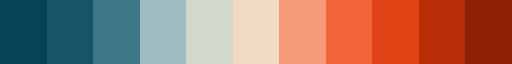

In [63]:
cmap_clusters = mcolors.LinearSegmentedColormap.from_list(
        f"white_to_test",
        ["#064455", "#1F6173", "#BED6D6", "#F1DBC3", "#F77044", "#D8370A", "#8D2002"],
        N=11
    )
cmap_clusters

In [64]:
color_dict = {
    "individual": {
        -1: "#9D9D9D",
        0: "#155567",
        1: "#3f7887",
        2: "#9ebfc2",
        3: "#d2d8ce",
        5: "#f1dbc3",
        6: "#f59b77",
        7:"#f16538",
        4:"#D8370A",
        # 8: "black",
        # 9: "red",
    },
    "collaborative": {
        -1: "#9D9D9D",
        6: "#155567",
        1: "#3f7887",
        5: "#9ebfc2",
        2: "#d2d8ce",
        3: "#f1dbc3",
        4: "#f59b77",
        7:"#f16538",
        0:"#D8370A"
    }
}
color_dict_tmp = color_dict[mode]

In [65]:
year=2023

In [66]:
df_plot = (
    df_dist_modes_mapping
    .query("year == @year")
    .merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .drop(columns=["alpha-2"])
    .rename(columns={"alpha-3": "country3"})
    .merge(df_total, on=["country", "year"])
)

gdf = world.merge(df_plot, left_on='ISO_A3_EH', right_on='country3')

gdf = gdf.to_crs(epsg=3857)
gdf['centroid'] = gdf.geometry.centroid

In [67]:
# (
#     df_plot
#     [["country", "year", "distance", "collab_share"]]
#     .merge(df_country[["alpha-2", "name", "region", "sub-region"]], left_on="country", right_on="alpha-2", how="left")
#     [["country", "name", "region", "sub-region", "distance", "collab_share"]]
# ).to_csv(PATH+f"show/df_national_international_2023.csv", index=False)

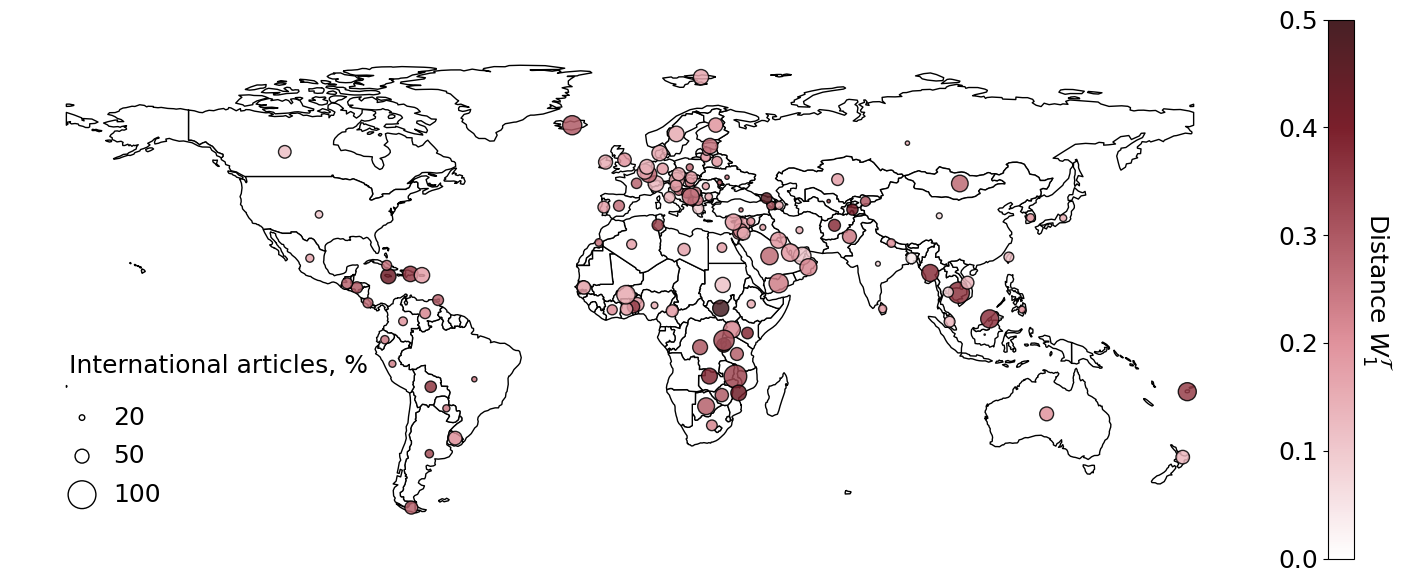

In [72]:
base_color = {
    1983: "#008000",
    2003: "#ff0000",
    2023: "#045A8D"
}
# cmap = white_to_color_red(base_color[year])
# cmap = white_to_color(base_color[year])
cmap = mcolors.LinearSegmentedColormap.from_list(name="test", colors=[(0, "white"), (0.4, "#E0929C"), (0.8, "#7A1F2B"), (1, "#472025")])
world = world[world['CONTINENT'] != 'Antarctica']

# Merge
gdf = world.merge(df_plot, left_on='ISO_A3_EH', right_on='country3')

# Convert BOTH to same CRS
world = world.to_crs(epsg=4326)
gdf = gdf.to_crs(epsg=4326)

# Compute centroids AFTER projection
gdf['point'] = gdf.geometry.representative_point()

# Plot
fig, ax = plt.subplots(figsize=(20, 7))

world.plot(ax=ax, color='white', edgecolor='#000000')

plt.scatter(-175, -50, s=(1 ** 2) * 400, edgecolor="black", color="none")
plt.scatter(-175, -38, s=(0.5 ** 2) * 400, edgecolor="black", color="none")
plt.scatter(-175, -26, s=(0.2 ** 2) * 400, edgecolor="black", color="none")

plt.text(-165, -50, "100", va="center", fontsize=18)
plt.text(-165, -38, "50", va="center", fontsize=18)
plt.text(-165, -26, "20", va="center", fontsize=18)

plt.text(-179, -10, "International articles, %", va="center",  fontsize=18)

# cmap = "#D8370A"

gdf.set_geometry('point').plot(
    ax=ax,
    markersize=(gdf['collab_share']**2) * 400,
    column='distance',              # 👈 color driven by dist
    cmap=cmap,             # choose colormap
    edgecolor='#000000',
    alpha=0.85,
    legend=True,               # 👈 adds colorbar
    vmin=0,
    vmax=0.5
)

fig = ax.get_figure()


cbar = ax.get_figure().axes[-1]  # last axis is usually the colorbar

plt.text(233, 13, r"Distance $W_1^{\mathcal{T}}$", va="center", fontsize=18, rotation=-90)

# cbar.set_ylabel(r"Distance $W_1^{\mathcal{T}}$", fontsize=16, rotation=-90, )
cbar.tick_params(labelsize=18, labelleft=True, labelright=False, right=False, left=True)
ax.axis('off')

# ax.set_title("DISTANCE BETWEEN DOMESTIC AND INTERNATIONAL PRODUCTION PROFILES", fontsize=18, fontweight="bold")
# fig.savefig(
#     f"map_collab_{year}.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )
# plt.show()
fig.savefig(f"../map_domestic_international.jpg", dpi=1000, bbox_inches='tight')

In [69]:
year_list_10y = np.arange(2023, 1975, -5)
# year_list_10y = np.arange(2023, 2002, -2)

In [ ]:
df_tmp = (
    res._df_mapping.query("(year in @year_list_10y)")
    .groupby(["dynamic_cluster", "year"], as_index=False).country.nunique()
    .sort_values(["year", "dynamic_cluster"], ascending=[False, True])
    .assign(
        # total_countries=lambda df: df.groupby("year").country.transform("sum"),
        country_share=lambda df: df.country / 195
    )
    .reset_index(drop=True)
)

In [ ]:
cluster_list = res._df_mapping.dynamic_cluster.sort_values().drop_duplicates().to_list()

In [ ]:
x_array = np.full(len(df_tmp), np.nan)
y_array = np.full(len(df_tmp), np.nan)
height_array = np.full(len(df_tmp), np.nan)
width_array = np.full(len(df_tmp), np.nan)
color_array = np.full(len(df_tmp), np.nan, dtype=object)
country_array = np.full(len(df_tmp), np.nan, dtype=object)
country_cluster_array = np.full(len(df_tmp), np.nan, dtype=object)

domain_list = ["Physical Sciences", "Health Sciences", "Social Sciences", "Life Sciences"]


In [ ]:
total_share = df_tmp.query("year == 2023").country_share.sum()
width = 0.2

array_idx = 0
next_year_dict = {}
for i, year_loop in enumerate(year_list_10y):
    cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    country_share_list = df_tmp.query("year == @year_loop").country_share.to_list()
    n_clusters = len(cluster_list_year)
    share_year = df_tmp.query("year == @year_loop").country_share.sum()
    # vert_space = (total_share - share_year) / (n_clusters + 1)
    vert_space = 0

    vert_coord = 0
    for j in range(n_clusters):
        # print(year_loop, cluster_list_year[j], country_share_list[j])
        x_array[array_idx] = len(year_list_10y) - i - width
        y_array[array_idx] = vert_coord + vert_space
        height_array[array_idx] = country_share_list[j]
        width_array[array_idx] = width  # width of the bar (10 years)
        color_array[array_idx] = color_dict_tmp[cluster_list_year[j]]
        vert_coord += country_share_list[j] + vert_space
        array_idx += 1

rectangles = list(tuple(zip(x_array, y_array, width_array, height_array)))
# rectangles_ps = list(tuple(zip(x_array_ps, y_array_ps, width_array_ps, height_array_ps)))

In [ ]:
# prev_y1 = {}
# for k, year_loop in enumerate(year_list_10y[1:]):
#     next_year_dict = {}
#     year_next = year_list_10y[k]
#     if k < len(year_list_10y) - 3:
#         year_prev = year_list_10y[k+2]
#         year_prev_prev = year_list_10y[k+3]
#     elif k < len(year_list_10y) - 2:
#         year_prev = year_list_10y[k+2]
#         year_prev_prev = None
#     else:
#         year_prev = None
#         year_prev_prev = None
#     cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    
#     for i in range(len(cluster_list_year)):
#         cluster_loop = cluster_list_year[i]
#         if year_prev_prev is not None:
#             df_cluster_year = (
#                 res._df_mapping.query("year == @year_loop")
#                 .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
#                 .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["", "_prev"])
#                 .merge(res._df_mapping.query("year == @year_prev_prev"), on="country", how="left", suffixes=["_cur", "_prev_prev"])
#                 .query("dynamic_cluster_cur == @cluster_loop")
#                 .sort_values(["dynamic_cluster_prev_prev", "dynamic_cluster_prev", "dynamic_cluster_next"])
#                 # .sort_values(["cluster_prev", "cluster_next"])
#             )
#         elif year_prev is not None:
#             df_cluster_year = (
#                 res._df_mapping.query("year == @year_loop")
#                 .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
#                 .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["_cur", "_prev"])
#                 .query("dynamic_cluster_cur == @cluster_loop")
#                 .sort_values(["dynamic_cluster_prev", "dynamic_cluster_next"])
#                 # .sort_values(["cluster_next"])
#             )
#         else:
#             df_cluster_year = (
#                 res._df_mapping.query("year == @year_loop")
#                 .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["_cur", "_next"])
#                 .query("dynamic_cluster_cur == @cluster_loop")
#                 .sort_values(["dynamic_cluster_next"])
#             )
#         # display(df_cluster_year)
#         n_countries = len(df_cluster_year)
#         cur_cluster_idx = df_tmp.query("(year == @year_loop) and (dynamic_cluster == @cluster_loop)").index[0]
#         # print(cur_cluster_idx)
#         country_step = height_array[cur_cluster_idx] / n_countries

#         x1_array = np.full(n_countries, np.nan)
#         y1_array = np.full(n_countries, np.nan)
#         x2_array = np.full(n_countries, np.nan)
#         y2_array = np.full(n_countries, np.nan)
#         c_array = np.full(n_countries, np.nan, dtype=object)

#         x1_cluster_array = np.full(n_countries, np.nan)
#         y1_cluster_array = np.full(n_countries, np.nan)
#         x2_cluster_array = np.full(n_countries, np.nan)
#         y2_cluster_array = np.full(n_countries, np.nan)
#         c_cluster_array = np.full(n_countries, np.nan, dtype=object)

#         next_year_list = df_cluster_year.dynamic_cluster_next.dropna().unique().tolist()
#         for next_cluster in next_year_list:
#             if next_cluster not in next_year_dict:
#                 next_cluster_idx = df_tmp.query("(year == @year_next) and (dynamic_cluster == @next_cluster)").index[0]
#                 next_year_dict[next_cluster] = y_array[next_cluster_idx]
       
#         y_cur = y_array[cur_cluster_idx]
#         for j, country in enumerate(df_cluster_year.country):
#             next_cluster = df_cluster_year.query("country == @country").dynamic_cluster_next.values[0]
#             y1_array[j] = y_cur
#             if np.isnan(next_cluster):
#                 continue
#             y2_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
#             x1_array[j] = len(year_list_10y) - k - 1
#             x2_array[j] = len(year_list_10y) - k - width
#             c_array[j] = country

#             y1_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
#             y2_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
#             x1_cluster_array[j] = len(year_list_10y) - k - width
#             x2_cluster_array[j] = len(year_list_10y) - k
#             c_cluster_array[j] = country

#             prev_y1[country] = y_cur

#             y_cur += country_step
#             next_year_dict[next_cluster] += country_step

#         country_array[cur_cluster_idx] = list(tuple(zip(x1_array, y1_array, x2_array, y2_array, c_array)))
#         country_cluster_array[cur_cluster_idx] = list(tuple(zip(x1_cluster_array, y1_cluster_array, x2_cluster_array, y2_cluster_array, c_cluster_array)))

#     # print(k, year_loop, year_next)

In [ ]:
prev_y1 = {}
for k, year_loop in enumerate(year_list_10y[1:]):
    next_year_dict = {}
    year_next = year_list_10y[k]
    if k < len(year_list_10y) - 3:
        year_prev = year_list_10y[k+2]
        # year_prev = None
        # year_prev_prev = year_list_10y[k+3]
        year_prev_prev = None
    elif k < len(year_list_10y) - 2:
        year_prev = year_list_10y[k+2]
        # year_prev = None
        year_prev_prev = None
    else:
        year_prev = None
        year_prev_prev = None
    cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    
    for i in range(len(cluster_list_year)):
        cluster_loop = cluster_list_year[i]
        if year_prev_prev is not None:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["", "_prev"])
                .merge(res._df_mapping.query("year == @year_prev_prev"), on="country", how="left", suffixes=["_cur", "_prev_prev"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_prev_prev", "dynamic_cluster_prev", "dynamic_cluster_next"])
                # .sort_values(["cluster_prev", "cluster_next"])
            )
        elif year_prev is not None:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["_cur", "_prev"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_prev", "dynamic_cluster_next"])
                # .sort_values(["cluster_next"])
            )
        else:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["_cur", "_next"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_next"])
            )
        # display(df_cluster_year)
        n_countries = len(df_cluster_year)
        cur_cluster_idx = df_tmp.query("(year == @year_loop) and (dynamic_cluster == @cluster_loop)").index[0]
        # print(cur_cluster_idx)
        country_step = height_array[cur_cluster_idx] / n_countries

        x1_array = np.full(n_countries, np.nan)
        y1_array = np.full(n_countries, np.nan)
        x2_array = np.full(n_countries, np.nan)
        y2_array = np.full(n_countries, np.nan)
        c_array = np.full(n_countries, np.nan, dtype=object)

        x1_cluster_array = np.full(n_countries, np.nan)
        y1_cluster_array = np.full(n_countries, np.nan)
        x2_cluster_array = np.full(n_countries, np.nan)
        y2_cluster_array = np.full(n_countries, np.nan)
        c_cluster_array = np.full(n_countries, np.nan, dtype=object)

        next_year_list = df_cluster_year.dynamic_cluster_next.dropna().unique().tolist()
        for next_cluster in next_year_list:
            if next_cluster not in next_year_dict:
                next_cluster_idx = df_tmp.query("(year == @year_next) and (dynamic_cluster == @next_cluster)").index[0]
                next_year_dict[next_cluster] = y_array[next_cluster_idx]
       
        y_cur = y_array[cur_cluster_idx]
        for j, country in enumerate(df_cluster_year.country):
            next_cluster = df_cluster_year.query("country == @country").dynamic_cluster_next.values[0]
            y1_array[j] = y_cur
            if np.isnan(next_cluster):
                continue
            y2_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_array[j] = len(year_list_10y) - k - 1
            x2_array[j] = len(year_list_10y) - k - width
            c_array[j] = country

            y1_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            y2_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_cluster_array[j] = len(year_list_10y) - k - width
            x2_cluster_array[j] = len(year_list_10y) - k
            c_cluster_array[j] = country

            prev_y1[country] = y_cur

            y_cur += country_step
            next_year_dict[next_cluster] += country_step

        country_array[cur_cluster_idx] = list(tuple(zip(x1_array, y1_array, x2_array, y2_array, c_array)))
        country_cluster_array[cur_cluster_idx] = list(tuple(zip(x1_cluster_array, y1_cluster_array, x2_cluster_array, y2_cluster_array, c_cluster_array)))

    # print(k, year_loop, year_next)

In [ ]:
def draw_flow(ax, x0, y0, x1, y1, curvature=0.5, color='grey', alpha=0.5, zorder=0):
    from matplotlib.path import Path
    import matplotlib.patches as patches

    dx = x1 - x0

    control1 = (x0 + curvature * dx, y0)
    control2 = (x1 - curvature * dx, y1)

    path = Path(
        [(x0, y0), control1, control2, (x1, y1)],
        [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    )

    patch = patches.PathPatch(
        path,
        facecolor='none',
        edgecolor=color,
        linewidth=1,
        alpha=alpha,
        zorder=zorder
    )

    ax.add_patch(patch)

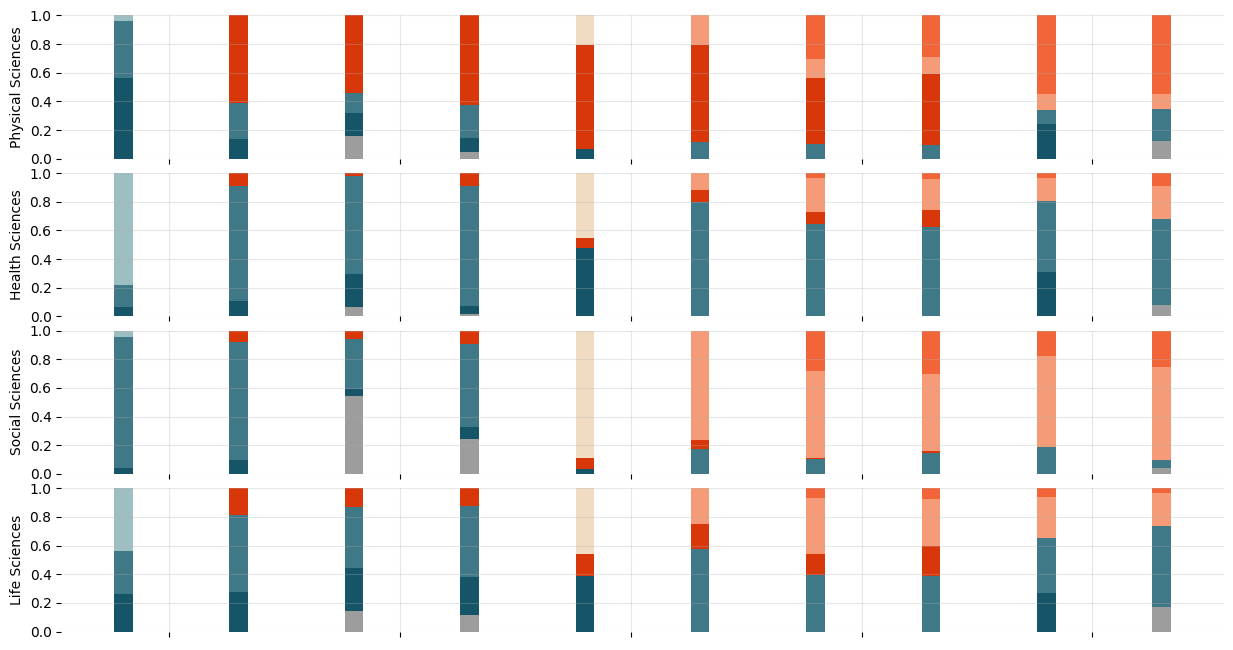

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(domain_list),
    ncols=1,
    figsize=(15, 2 * len(domain_list)),
    sharex=True
)

# If only one domain, make axes iterable
if len(domain_list) == 1:
    axes = [axes]

for ax, domain in zip(axes, domain_list):
    # Prepare data
    df_pivot = (
        sc._pos_metric_norm
        # [[domain]]
        [df_subfield.query("domain_name == @domain").subfield_id.to_list()]
        .query("year in @year_list_10y")
        .replace({0 : np.nan})
        .sum(axis=1)
        .reset_index()
        .pivot(index="year", columns="dynamic_cluster")
        .fillna(0)
        .sort_index()
    )[0]
    df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    x = df_pivot.index

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_pivot))
    neg_sum = np.zeros(len(df_pivot))
    bottom = 0
    for i, col in enumerate(df_pivot.columns):
        ax.bar(
            df_pivot.index,
            df_pivot[col],
            bottom=bottom,
            label=col,
            color=color_dict_tmp[col],
            width=0.8
        )
        
        # Update bottom for stacking
        if bottom is None:
            bottom = df_pivot[col].values
        else:
            bottom = bottom + df_pivot[col].values
        # Baseline
        # ax.axhline(0, color="grey", linewidth=1)
        # ax.axhline(1, color="grey", linewidth=4)

        # Limits and labels
        # ax.set_ylim(-1, 1)
        ax.set_ylabel(domain)

        # Grid
        # ax.set_yticks([-0.5, 0, 0.5])
        # ax.tick_params(axis='y', pad=2)
        ax.grid(alpha=0.3)

# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0.1)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # ax.spines["right"].set_color("grey")
    # ax.spines["right"].set_linewidth(2)
    ax.spines["left"].set_visible(False)
    # ax.spines["left"].set_linewidth(2)
    # ax.spines["top"].set_color("grey")
    # ax.spines["top"].set_linewidth(2)
    # ax.spines["bottom"].set_color("grey")
    # ax.spines["bottom"].set_linewidth(2)
    # Top spine only for first plot
    # if i == 0:
    #     ax.spines['top'].set_visible(True)
    # else:
    #     ax.spines['top'].set_visible(False)

    # Bottom spine only for last plot
    # if i == len(axes) - 1:
    #     ax.spines['bottom'].set_visible(True)
    # else:
    #     ax.spines['bottom'].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.set_xticklabels([])

# axes[-1].set_xticks(x)
# axes[-1].set_xticklabels(x)

plt.show()

In [ ]:
(
        sc._pos_metric_norm
        [df_subfield.query("domain_name == @domain").subfield_id.to_list()]
        .query("year in @year_list_10y")
        .replace({0 : np.nan})
        .sum(axis=1)
        .to_frame("sum_domain")
        .reset_index()
        .pivot(index="year", columns="dynamic_cluster", values="sum_domain")
        .replace({0: np.nan})
        .sort_index()
)

dynamic_cluster,-1,0,1,2,4,5,6,7
year,,,,,,,,
1978,NaN,10.196059,11.763702,17.04024,NaN,NaN,NaN,NaN
1983,NaN,11.012145,21.409624,NaN,7.578232,NaN,NaN,NaN
1988,5.879270,12.380872,17.491263,NaN,5.248595,NaN,NaN,NaN
1993,4.533581,10.569699,19.946691,NaN,4.950028,NaN,NaN,NaN
1998,NaN,15.875495,NaN,NaN,6.414485,18.71002,NaN,NaN
2003,NaN,NaN,22.975233,NaN,7.047097,NaN,9.977670,NaN
2008,NaN,NaN,16.158455,NaN,6.011935,NaN,16.131711,2.697899
2013,NaN,NaN,16.016314,NaN,8.495210,NaN,13.473419,3.015056
2018,NaN,11.021826,15.875896,NaN,NaN,NaN,11.723757,2.378521


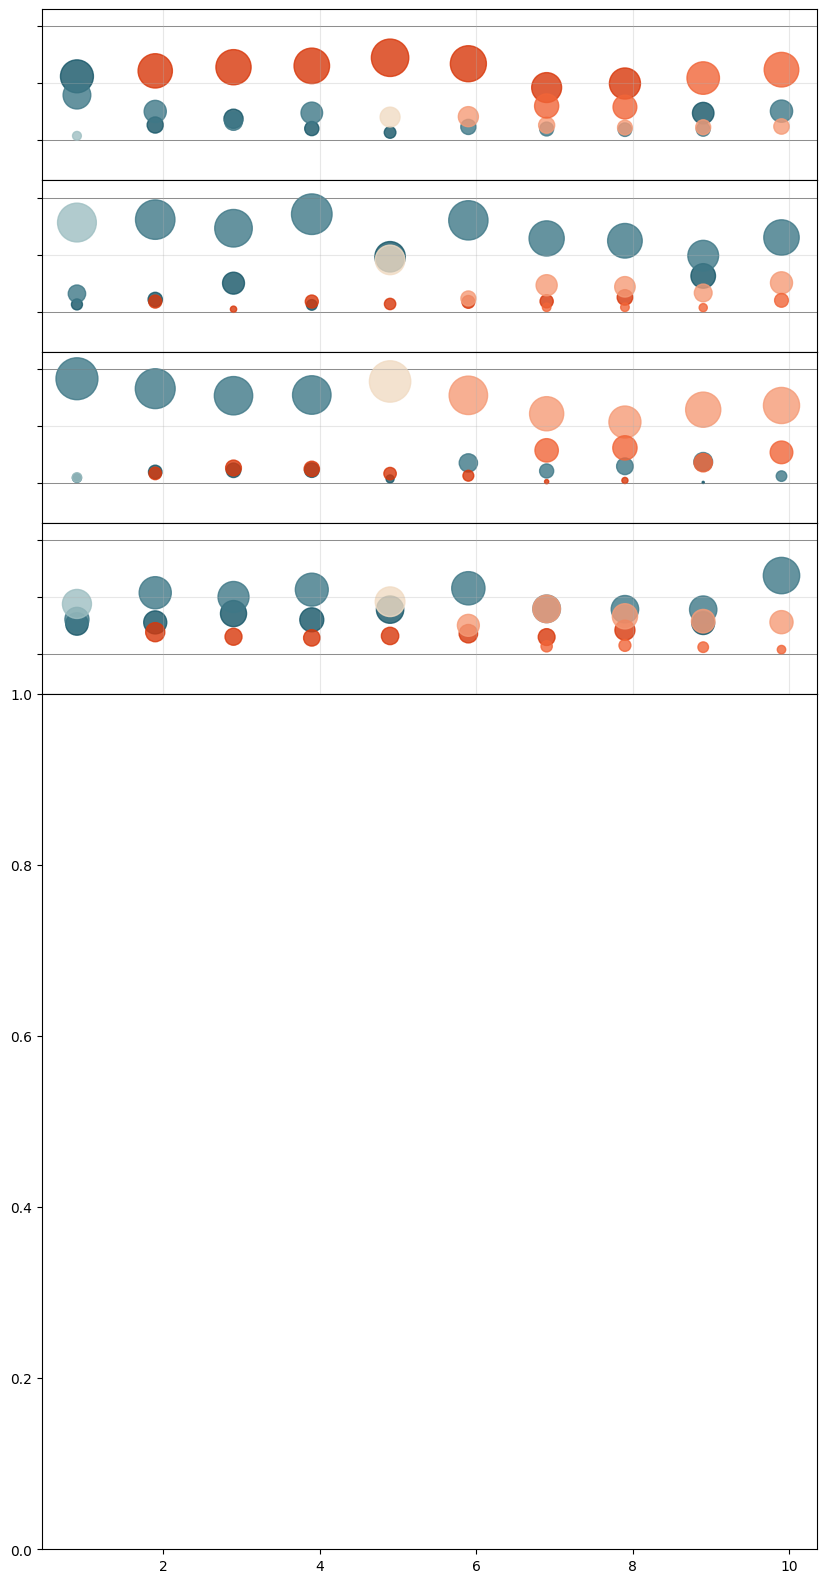

In [ ]:
# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(domain_list)+1,
    ncols=1,
    figsize=(10, 4 * (len(domain_list)+1)),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1]*len(domain_list) + [5]   # 👈 last plot is 2x taller

    }
)

ax2 = axes[-1]

# If only one domain, make axes iterable
if len(domain_list) == 1:
    axes = [axes]

for ax, domain in zip(axes[:-1], domain_list):
    # Prepare data
    df_pivot = (
        sc._pos_metric_norm
        [df_subfield.query("domain_name == @domain").subfield_id.to_list()]
        .query("(year in @year_list_10y) and (dynamic_cluster != -1)")
        .replace({0 : np.nan})
        .sum(axis=1)
        .to_frame("sum_domain")
        .reset_index()
        .pivot(index="year", columns="dynamic_cluster", values="sum_domain")
        .replace({0: np.nan})
        .sort_index()
    )
    df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    x = np.arange(len(df_pivot.index))+1-width/2
    

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_pivot))
    neg_sum = np.zeros(len(df_pivot))

    for i, col in enumerate(df_pivot.columns):
        ax.scatter(
            x,
            df_pivot[col],
            # bottom=bottom,
            label=col,
            color=color_dict_tmp[col],
            s=df_pivot[col]*1000,
            alpha=0.8
        )
        ax.axhline(1, color="grey", linewidth=0.5, zorder=0)
        ax.axhline(0, color="grey", linewidth=0.5, zorder=0)
        ax.axhline(-1, color="grey", linewidth=0.5, zorder=0)
        ax.set_ylim(-0.35, 1.15)
        # ax.set_ylabel(domain)

        # Grid
        ax.set_yticks([0, 0.5, 1], labels=[None]*3)
        # ax.set_xticks([])
        ax.tick_params(axis='y', pad=2)
        ax.grid(alpha=0.3)
x = np.arange(len(year_list_10y))+1-width/2
# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes[:-1]):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines["left"].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.tick_params(axis='y', color='none')
    ax.tick_params(axis='x', color='none')
    ax.set_xticklabels([])

to_print_list = ["US", "CN", "RU", "IT", "FR", "IN", "ID", "BR"]
printed_list = []
for i, (x, y, w, h) in enumerate(rectangles):
    rect = patches.Rectangle(
        (x, y), w, h,
        edgecolor=None,
        facecolor=color_array[rectangles.index((x, y, w, h))],
        zorder=1
    )
    ax2.add_patch(rect)
    
    if not isinstance(country_array[i], list):
        continue
    for (x0, y0, x1, y1, c) in country_array[i]:
        if c in to_print_list:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="grey", alpha=0.8, zorder=2)
        else:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="lightgrey", alpha=0.3, zorder=2)

    for (x0, y0, x1, y1, c) in country_cluster_array[i]:
        if c in to_print_list:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.6, zorder=2)
            if c not in printed_list:
                ax2.text(x1+0.02, y1, c, ha='left', va='center', fontdict={"size": 8, "family":"sans-serif"})
                printed_list.append(c)
        else:
            draw_flow(ax2, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.2, zorder=2)


# for year in year_list_10y:
#     x_text = len(year_list_10y) - list(year_list_10y).index(year) - width
#     y_text = df_tmp.query("year == @year").country_share.sum() + 0.01
#     ax2.text(x_text, y_text, str(year), ha='left', va='bottom', fontdict={"size": 9, "family":"sans-serif"})

ax2.set_xlim(-1.5, 11)
ax2.set_ylim(0, 1 + 0.1)

ax2.set_xticks([])
ax2.set_yticks(np.linspace(0, 1, 6), labels=[None]*6)
ax2.tick_params(axis='y', color='none')
ax2.tick_params(axis='x', color='none')
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("left")

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['right'].set_color("grey")
ax2.spines['bottom'].set_color("grey")

ax2.grid(axis='y', linestyle='-', linewidth=0.8, alpha=0.25, zorder=0)

x = np.arange(len(year_list_10y))+1-width/2
for ax in axes:
    ax.set_xticks(x)
    ax.grid(axis='x', linestyle='-', linewidth=0.8, alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    
# plt.savefig(f"fig_{mode}.svg",format="svg",
#     transparent=True,)
# ax2.grid("both", alpha=0.3)

In [ ]:
res._df_mapping.query("year == 1998").dynamic_cluster.unique()

array([1, 2, 0])

In [ ]:
(
    res._silhouette_score
    .copy()
    .assign(
        ari_score_mean=res._ari_score_mean,
        ari_score_std=res._ari_score_std,
        modularity=res._modularity,
    )
    .rename(columns={"score": "silhouette_score"})
).to_csv(PATH+f"show/scores_{mode}.csv")

In [ ]:
pd.DataFrame([res._ari_score_mean,
res._ari_score_std,
res._modularity,
])

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.745022,0.644776,0.638261,0.720456,0.828578,0.964537,0.834375,0.735530,0.872999,0.842024
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.228470,0.193002,0.209676,0.179171,0.203847,0.069270,0.122268,0.142422,0.162345,0.141948
2,0.195349,0.214286,0.180995,0.212389,0.210491,0.220994,0.189034,0.227273,0.222453,0.228435,...,0.234173,0.218764,0.216005,0.245181,0.274053,0.289947,0.239218,0.229147,0.261183,0.284702


In [ ]:
# plt.subplots(figsize = (10, 5))
# plt.plot(res._year_list, res._ari_score_mean, color="#8d2002")
# plt.scatter(res._year_list, res._ari_score_mean, color="#8d2002")
# plt.grid()
# plt.ylim([0, 1.1])

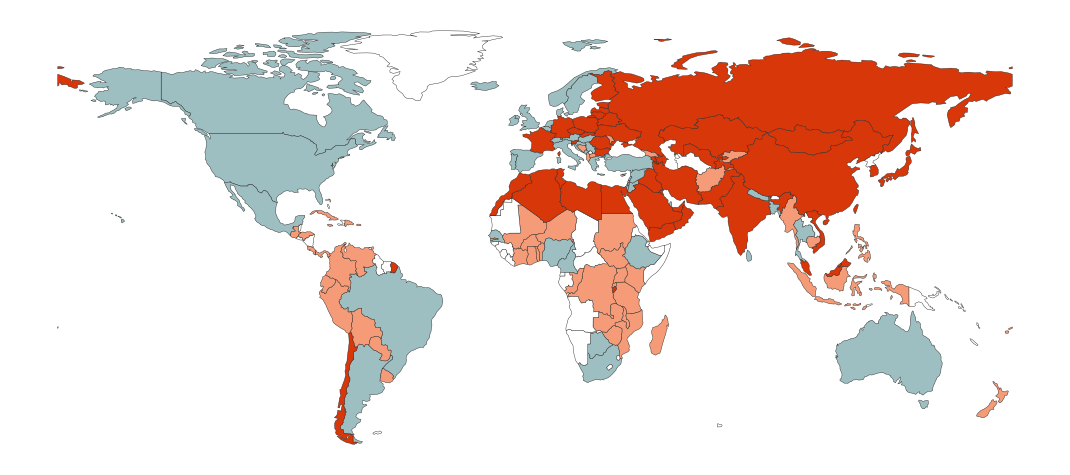

In [ ]:
# map with clusters
year = 2023
# --- 4. Merge with world map ---
world_ = world.merge(
    res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

# fallback for missing
world_["color"] = world_["color"].fillna("white")

# legend_elements = []
# for cluster, color in color_dict_tmp.items():
#     if cluster in res._df_mapping.query("year == @year").dynamic_cluster.to_list():
#         label = names_dict_cluster.get(cluster, str(cluster))
        
#         legend_elements.append(
#             Patch(facecolor=color, edgecolor="black", label=label)
#         )

fig, ax = plt.subplots(figsize=(14, 7))
fig.set_constrained_layout(False)

fig.subplots_adjust(left=0.05, right=0.8, top=0.9, bottom=0.25)

world_.plot(
    color=world_["color"],
    edgecolor="#242424",
    linewidth=0.3,
    ax=ax
)

ax.set_axis_off()
# ax.set_title(f"Clusters in {year}")
ax.set_aspect('auto')

    
# plt.savefig(f"map_{mode}.svg",format="svg",
    # transparent=True,)
# plt.show()